<a href="https://colab.research.google.com/github/felipits/ANI-asistente-normativo/blob/main/P2_evaluacion_IL14.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -q pymupdf

from google.colab import drive
drive.mount('/content/drive')

import glob, os, fitz

PROBAR = False   # True solo si quieres ver las pruebas de cada paso

# Busca la carpeta ANI en el Drive de quien ejecuta el notebook (sirve para Felipe y para Adolfo)
carpetas = [c for c in glob.glob('/content/drive/MyDrive/**/ANI', recursive=True)
            if os.path.exists(os.path.join(c, "Decreto_67_2018.pdf"))]
print("Carpeta encontrada:", carpetas)
CARPETA = carpetas[0]

for f in sorted(glob.glob(os.path.join(CARPETA, '*.pdf'))):
    doc = fitz.open(f)
    texto = "".join(p.get_text() for p in doc)
    print(f"{os.path.basename(f)}: {doc.page_count} páginas, {len(texto):,} caracteres")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Carpeta encontrada: ['/content/drive/MyDrive/Ingenieria de Soluciones con IA/ANI']
Decreto_67_2018.pdf: 9 páginas, 28,645 caracteres
Reglamento_Convivencia.pdf: 194 páginas, 554,553 caracteres
Reglamento_Evaluacion_2026.pdf: 40 páginas, 91,908 caracteres


In [ ]:
# ============================================================
# PASO 6 · Cortar los documentos en fragmentos citables
# ============================================================
!pip install -q pymupdf
import re, os, json
import pymupdf

DOCUMENTOS = [
    # archivo, nombre para citar, tipo (interna/externa), año, páginas de portada/índice que se saltan
    ("Reglamento_Evaluacion_2026.pdf", "Reglamento de Evaluación y Promoción 2026", "interna", 2026, 3),
    ("Reglamento_Convivencia.pdf",     "Reglamento Interno de Convivencia Escolar 2026", "interna", 2026, 3),
    ("Decreto_67_2018.pdf",            "Decreto 67/2018 (MINEDUC)", "externa", 2018, 0),
]

# ---------- 1. Limpieza de líneas ----------
RUIDO = [
    re.compile(r"^\s*\d{1,3}\s*$"),                      # números de página sueltos
    re.compile(r"^\s*[•●▪§\-–]\s*$"),                    # viñetas vacías
    re.compile(r"\.{5,}"),                               # líneas del índice (.......)
    re.compile(r"^Decreto 67, EDUCACI"),                 # encabezado BCN
    re.compile(r"^Biblioteca del Congreso Nacional"),    # encabezado BCN
    re.compile(r"^página \d+ de \d+"),                   # pie BCN
]

def limpiar(linea):
    linea = linea.replace("\u00a0", " ").strip()
    if not linea or any(p.search(linea) for p in RUIDO):
        return None
    return linea

# ---------- 2. Detección de títulos según el documento ----------
ART  = re.compile(r"^Art[íi]culo\s+(\d+)\s*[°º]?\s*\.?\s*-")
SEC_EVAL = re.compile(r"^(\d{1,2})\s*\.-?\s*([A-ZÁÉÍÓÚÑ][A-ZÁÉÍÓÚÑ ,;()\.]{4,})$")
ROMANO = re.compile(r"^([IVX]{1,4})\s*\.\s*(.{4,})$")
SUBSEC = re.compile(r"^(\d{1,2}\.\d{1,2}(?:\.\d{1,2})?)\.?(?:\s+([A-ZÁÉÍÓÚÑ¿].*)|\s*)$")
PROTO  = re.compile(r"^(\d{1,2})\s*[\.\-]\s*(PROTOCOLO\b.*|Protocolo\b.*)$")

TITULOS_FIJOS = {14: "Protocolo de manejo de estudiantes con tratamiento farmacológico"}  # título partido en el PDF

def titulo_corto(t, n=90):
    t = re.sub(r"\s+", " ", t).strip(" .:")
    return t[:n]

def segmentar(ruta, nombre, tipo, anio, saltar=0):
    doc = pymupdf.open(ruta)
    secciones = []
    ctx = {"seccion": "", "protocolo": "", "punto": "", "articulo": ""}
    num_sec, num_proto = 0, 0   # los números de sección/protocolo solo pueden avanzar
    actual = {"texto": [], "pag_ini": 1, "etiqueta": "Inicio"}
    num_suelto = None
    pendiente = None   # título partido en dos líneas (ej: "4.7" y el título abajo)

    def etiqueta():
        partes = []
        if ctx["protocolo"]:
            partes.append(ctx["protocolo"])
        elif ctx["seccion"]:
            partes.append(ctx["seccion"])
        if ctx["punto"]:
            partes.append(ctx["punto"])
        if ctx["articulo"]:
            partes.append(ctx["articulo"])
        return " · ".join(partes) or "Inicio"

    def cerrar(pag):
        if actual["texto"]:
            secciones.append({**actual, "pag_fin": pag, "texto": "\n".join(actual["texto"])})
        actual.update({"texto": [], "pag_ini": pag, "etiqueta": etiqueta()})

    for num_pag, pagina in enumerate(doc, start=1):
        if num_pag <= saltar:
            continue
        for bruta in pagina.get_text().split("\n"):
            linea = limpiar(bruta)
            if linea is None:
                continue
            if "Convivencia" in ruta and re.fullmatch(r"\d{1,2}\s*[\.\-]", linea):
                num_suelto = linea                  # ej: "14." y en la línea siguiente "Protocolo de..."
                continue
            if "Convivencia" in ruta and num_suelto:
                if linea.lower().startswith("protocolo"):
                    linea = f"{num_suelto} {linea}"
                else:
                    actual["texto"].append(num_suelto)
                num_suelto = None
            if pendiente:                       # completar título partido
                linea_titulo = f"{pendiente} {linea}"
                pendiente = None
                cerrar(num_pag)
                ctx["punto"] = f"punto {titulo_corto(linea_titulo, 80)}"
                actual["etiqueta"] = etiqueta()
                actual["texto"].append(linea_titulo)
                continue

            es_titulo = False
            m_art = ART.match(linea)
            if m_art:
                cerrar(num_pag); es_titulo = True
                ctx["articulo"] = f"Art. {m_art.group(1)}°"
                if tipo == "externa":
                    ctx["punto"] = ""

            elif "Evaluacion" in ruta and SEC_EVAL.match(linea):
                m = SEC_EVAL.match(linea)
                cerrar(num_pag); es_titulo = True
                n = int(m.group(1))
                if n > num_sec:                    # nueva sección del reglamento
                    num_sec = n
                    ctx["seccion"] = f"Sección {n} {titulo_corto(m.group(2), 60)}"
                    ctx["punto"], ctx["articulo"] = "", ""
                else:                              # numeración interna (ej. sección TP)
                    ctx["punto"] = f"punto {n} {titulo_corto(m.group(2), 60)}"

            elif "Convivencia" in ruta:
                m_p, m_r, m_s = PROTO.match(linea), ROMANO.match(linea), SUBSEC.match(linea)
                if not num_proto and linea.upper().startswith("PROTOCOLO DE ALUMNAS EN SITUACI"):
                    m_p = re.match(r"(1)(.*)", "1" + linea)       # el protocolo 1 no trae número
                if m_p and num_proto < int(m_p.group(1)) <= 17:
                    num_proto = int(m_p.group(1))
                    cerrar(num_pag); es_titulo = True
                    titulo = TITULOS_FIJOS.get(num_proto, m_p.group(2))
                    ctx["protocolo"] = f"Protocolo {num_proto}: {titulo_corto(titulo, 70)}"
                    ctx["punto"] = ""
                elif m_r and not ctx["protocolo"]:
                    cerrar(num_pag); es_titulo = True
                    ctx["seccion"] = f"Título {m_r.group(1)} {titulo_corto(m_r.group(2), 60)}"
                    ctx["punto"] = ""
                elif m_s and len(linea) < 140:
                    if not (m_s.group(2) or "").strip():
                        pendiente = m_s.group(1)   # el título viene en la línea siguiente
                        continue
                    cerrar(num_pag); es_titulo = True
                    ctx["punto"] = f"punto {m_s.group(1)} {titulo_corto(m_s.group(2) or '', 70)}"

            if es_titulo:
                actual["etiqueta"] = etiqueta()
            actual["texto"].append(linea)
    cerrar(doc.page_count)

    for s in secciones:
        s.update({"documento": nombre, "tipo": tipo, "anio": anio})
    return [s for s in secciones if len(s["texto"]) > 80]

# ---------- 3. Cortar secciones largas en fragmentos ----------
def fragmentar(seccion, max_chars=1500, solape=200):
    texto = re.sub(r"\n(?=[a-záéíóúñ,;])", " ", seccion["texto"])   # une líneas cortadas
    if len(texto) <= max_chars:
        partes = [texto]
    else:
        partes, inicio = [], 0
        while inicio < len(texto):
            fin = min(inicio + max_chars, len(texto))
            if fin < len(texto):                       # cortar en un salto de línea
                corte = texto.rfind("\n", inicio + max_chars // 2, fin)
                fin = corte if corte != -1 else fin
            partes.append(texto[inicio:fin])
            if fin >= len(texto):
                break
            inicio = max(fin - solape, inicio + 1)
    return [{
        "texto": p.strip(),
        "documento": seccion["documento"], "tipo": seccion["tipo"], "anio": seccion["anio"],
        "ubicacion": seccion["etiqueta"],
        "paginas": f"{seccion['pag_ini']}-{seccion['pag_fin']}" if seccion['pag_ini'] != seccion['pag_fin'] else str(seccion['pag_ini']),
        "parte": f"{i+1}/{len(partes)}",
    } for i, p in enumerate(partes)]

def construir_fragmentos(carpeta):
    fragmentos = []
    for archivo, nombre, tipo, anio, saltar in DOCUMENTOS:
        secs = segmentar(os.path.join(carpeta, archivo), nombre, tipo, anio, saltar)
        frs = [f for s in secs for f in fragmentar(s)]
        print(f"{nombre}: {len(secs)} secciones → {len(frs)} fragmentos")
        fragmentos += frs
    for i, f in enumerate(fragmentos):
        f["id"] = f"frag_{i:04d}"
    return fragmentos

# ---------- 4. Ejecutar y guardar ----------
# CARPETA se define en la primera celda (funciona en la cuenta de cada integrante)
fragmentos = construir_fragmentos(CARPETA)
print("Total de fragmentos:", len(fragmentos))

with open(os.path.join(CARPETA, "fragmentos.json"), "w", encoding="utf-8") as f:
    json.dump(fragmentos, f, ensure_ascii=False, indent=1)

# Revisión: el fragmento de la reprogramación de pruebas
ejemplo = next(f for f in fragmentos if "recuperativa o reprogramación" in f["texto"])
print("\nEjemplo →", ejemplo["documento"], "|", ejemplo["ubicacion"], "| pág.", ejemplo["paginas"])
print(ejemplo["texto"][-500:])

Reglamento de Evaluación y Promoción 2026: 39 secciones → 91 fragmentos
Reglamento Interno de Convivencia Escolar 2026: 142 secciones → 505 fragmentos
Decreto 67/2018 (MINEDUC): 25 secciones → 34 fragmentos
Total de fragmentos: 630

Ejemplo → Reglamento de Evaluación y Promoción 2026 | Sección 6 DISPOSICIONES · Art. 5° | pág. 11-12
edimento de manera explícita y en el momento que corresponda y no a fin de año.
En casos en que los y las estudiantes no puedan rendir evaluaciones en las fechas establecidas por motivos debidamente justificados, el establecimiento deberá garantizar instancias de evaluación recuperativa o reprogramación, resguardando la adecuada evaluación de los aprendizajes. Estas medidas podrán enmarcarse dentro de un Plan de Acompañamiento Individual (PAI), cuando la situación del estudiante así lo requiera.


In [ ]:
# ============================================================
# PASO 7 · Índice RAG: embeddings + ChromaDB (2 colecciones)
# ============================================================
!pip install -q chromadb sentence-transformers

import json, os, chromadb
from sentence_transformers import SentenceTransformer

# CARPETA se define en la primera celda (funciona en la cuenta de cada integrante)
with open(os.path.join(CARPETA, "fragmentos.json"), encoding="utf-8") as f:
    fragmentos = json.load(f)

# Modelo de embeddings multilingüe (corre en CPU, gratis)
modelo_emb = SentenceTransformer("intfloat/multilingual-e5-small")

def emb_pasajes(textos):
    return modelo_emb.encode(["passage: " + t for t in textos], normalize_embeddings=True,
                             batch_size=32, show_progress_bar=True).tolist()

def emb_consulta(texto):
    return modelo_emb.encode(["query: " + texto], normalize_embeddings=True).tolist()

# Base vectorial con dos colecciones: norma interna y norma externa
cliente_db = chromadb.PersistentClient(path="/content/chroma_ani")
colecciones = {}
for tipo in ["interna", "externa"]:
    nombre = f"norma_{tipo}"
    try:
        cliente_db.delete_collection(nombre)      # si ya existía, se reconstruye
    except Exception:
        pass
    col = cliente_db.create_collection(nombre, metadata={"hnsw:space": "cosine"})
    frs = [f for f in fragmentos if f["tipo"] == tipo]
    textos_para_emb = [f"{f['documento']} | {f['ubicacion']}\n{f['texto']}" for f in frs]
    col.add(
        ids=[f["id"] for f in frs],
        documents=[f["texto"] for f in frs],
        embeddings=emb_pasajes(textos_para_emb),
        metadatas=[{k: f[k] for k in ("documento", "tipo", "anio", "ubicacion", "paginas", "parte")} for f in frs],
    )
    colecciones[tipo] = col
    print(f"Colección {nombre}: {col.count()} fragmentos")

# Función de búsqueda (la usará el agente más adelante)
def buscar(consulta, tipo="interna", k=4):
    r = colecciones[tipo].query(query_embeddings=emb_consulta(consulta), n_results=k)
    return [{"texto": doc, **meta, "similitud": round(1 - dist, 3)}
            for doc, meta, dist in zip(r["documents"][0], r["metadatas"][0], r["distances"][0])]

# Pruebas con preguntas en lenguaje cotidiano
pruebas = [
    ("Mi hijo se enfermó y faltó a la prueba, ¿qué pasa?", "interna"),
    ("¿Cuánto plazo tengo para justificar una inasistencia?", "interna"),
    ("Le están haciendo bullying a mi hija, ¿qué hace el liceo?", "interna"),
    ("¿Con qué porcentaje de asistencia se repite de curso?", "externa"),
]
for pregunta, tipo in pruebas:
    print(f"\n❓ {pregunta}  [norma {tipo}]")
    for r in buscar(pregunta, tipo, k=3):
        print(f"   {r['similitud']:.3f} | {r['documento']} | {r['ubicacion'][:75]} | pág. {r['paginas']}")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Batches:   0%|          | 0/19 [00:00<?, ?it/s]

Colección norma_interna: 596 fragmentos


Batches:   0%|          | 0/2 [00:00<?, ?it/s]

Colección norma_externa: 34 fragmentos

❓ Mi hijo se enfermó y faltó a la prueba, ¿qué pasa?  [norma interna]
   0.837 | Reglamento Interno de Convivencia Escolar 2026 | Protocolo 4: PROTOCOLO DE NORMAS DE CONVIVENCIA ESCOLAR Y FALTAS · punto 4. | pág. 76-91
   0.837 | Reglamento Interno de Convivencia Escolar 2026 | Protocolo 7: PROTOCOLO FRENTE A SITUACIONES DE VULNERACIÓN DE DERECHOS DE E | pág. 109-117
   0.834 | Reglamento Interno de Convivencia Escolar 2026 | Protocolo 9: PROTOCOLO DE RESPUESTA Y ATENCIÓN A SITUACIONES DE DESREGULACI | pág. 120-131

❓ ¿Cuánto plazo tengo para justificar una inasistencia?  [norma interna]
   0.869 | Reglamento Interno de Convivencia Escolar 2026 | Título IV REGULACIONES GENERALES · punto 4.5 Asistencia, atrasos y retiro d | pág. 23
   0.864 | Reglamento Interno de Convivencia Escolar 2026 | Protocolo 1: PROTOCOLO DE ALUMNAS EN SITUACIÓN DE EMBARAZO, Y DE ALUMNAS O  | pág. 42
   0.854 | Reglamento Interno de Convivencia Escolar 2026 | Protocolo 7: 

In [ ]:
# ============================================================
# PASO 8 · Búsqueda por dominio (evaluación / convivencia)
# ============================================================
DOMINIOS = {
    "evaluacion":  "Reglamento de Evaluación y Promoción 2026",
    "convivencia": "Reglamento Interno de Convivencia Escolar 2026",
}

def buscar(consulta, tipo="interna", k=4, dominio=None):
    filtro = {"documento": DOMINIOS[dominio]} if dominio else None
    r = colecciones[tipo].query(query_embeddings=emb_consulta(consulta), n_results=k, where=filtro)
    return [{"texto": doc, **meta, "similitud": round(1 - dist, 3)}
            for doc, meta, dist in zip(r["documents"][0], r["metadatas"][0], r["distances"][0])]

pruebas = [
    ("Mi hijo se enfermó y faltó a la prueba, ¿qué pasa?", "evaluacion"),
    ("Le están haciendo bullying a mi hija, ¿qué hace el liceo?", "convivencia"),
    ("¿Qué pasa si mi hijo se copia en una prueba?", "evaluacion"),
    ("¿Pueden suspender a mi hijo?", "convivencia"),
]
for pregunta, dominio in pruebas:
    print(f"\n❓ {pregunta}  [dominio: {dominio}]")
    for i, r in enumerate(buscar(pregunta, dominio=dominio, k=3)):
        print(f"   {r['similitud']:.3f} | {r['ubicacion'][:80]} | pág. {r['paginas']}")
        if i == 0:
            print("        →", r["texto"][:160].replace("\n", " "), "...")


❓ Mi hijo se enfermó y faltó a la prueba, ¿qué pasa?  [dominio: evaluacion]
   0.828 | Sección 6 DISPOSICIONES · Art. 5° | pág. 11-12
        → registra en la hoja de vida, se cita y se comunica al apoderado(a) el comportamiento del o la estudiante. El o la apoderado(a) debe asegurar y garantizar la rea ...
   0.825 | Sección 10 SITUACIONES ESPECIALES DE EVALUACIÓN Y PROMOCIÓN | pág. 21-22
   0.823 | Sección 14 PROYECTOS TP Y PRÁCTICAS PROFESIONALES · punto 12 OTROS ASPECTOS QUE  | pág. 36-39

❓ Le están haciendo bullying a mi hija, ¿qué hace el liceo?  [dominio: convivencia]
   0.859 | Protocolo 4: PROTOCOLO DE NORMAS DE CONVIVENCIA ESCOLAR Y FALTAS · punto 4.2.4 F | pág. 76-91
        → esentación del liceo. p) Cualquier tipo de atentado contra la integridad física, psíquica o psicológica de alguno de los miembros de la comunidad educativa que  ...
   0.857 | Protocolo 4: PROTOCOLO DE NORMAS DE CONVIVENCIA ESCOLAR Y FALTAS · punto 4.2.4 F | pág. 76-91
   0.855 | Protocolo 4: PROTOCO

In [ ]:
# ============================================================
# PASO 9 · RAG simple: búsqueda + prompt de sistema + Gemini
# ============================================================
from google import genai
from google.genai import types
from google.colab import userdata

client = genai.Client(api_key=userdata.get("GEMINI_API_KEY"))
MODELO = "gemini-3.1-flash-lite"   # el con más cuota diaria (antes: gemini-3.5-flash)

PROBAR = globals().get("PROBAR", False)   # si no está definido en la primera celda, no prueba

PROMPT_SISTEMA = """Eres ANI, el Asistente Normativo Institucional del Liceo Guillermo Labarca Hubertson (Quinta Normal, Chile).

REGLAS
1. Responde SOLO con la información de los FRAGMENTOS entregados. No uses conocimiento externo.
2. Cita siempre el documento, la ubicación (artículo, sección, punto o protocolo) y la página.
3. Si los fragmentos no responden la pregunta, di exactamente: "No está regulado en los documentos disponibles." y sugiere a quién acudir (UTP, Inspectoría General o Convivencia Escolar).
4. Si hay norma interna y externa, explica cómo se relacionan: el reglamento del liceo se aplica primero si respeta los mínimos del Decreto 67, que rige de forma supletoria (Art. 3° del Reglamento de Evaluación).
5. No respondas sobre casos de personas identificadas ni pidas datos personales.
6. Usa lenguaje simple, pensado para apoderados que pueden no conocer el sistema educativo chileno.

FORMATO
- Respuesta breve (máximo 6 líneas).
- Luego: "📄 Fuente: <documento>, <ubicación>, pág. <páginas>."
- Cierra con: "ℹ️ Apoyo informativo: no reemplaza la decisión de UTP, Convivencia o Dirección."
"""

def formatear_contexto(frs):
    return "\n\n".join(
        f"[F{i+1}] {f['documento']} ({f['anio']}) | {f['ubicacion']} | pág. {f['paginas']}\n{f['texto']}"
        for i, f in enumerate(frs))

def responder(pregunta, dominio=None, k=4):
    frs = buscar(pregunta, "interna", k=k, dominio=dominio)
    r = client.models.generate_content(
        model=MODELO,
        contents=f"FRAGMENTOS:\n{formatear_contexto(frs)}\n\nPREGUNTA: {pregunta}",
        config=types.GenerateContentConfig(system_instruction=PROMPT_SISTEMA, temperature=0.2),
    )
    return r.text, frs

# ---------- Pruebas (solo si PROBAR = True, para no gastar cuota) ----------
pruebas = [
    ("Mi hijo se enfermó y faltó a la prueba, ¿qué pasa?", "evaluacion"),
    ("¿Cuánto plazo tengo para justificar una inasistencia?", "convivencia"),
    ("¿Cuánto cuesta la cuota del centro de padres?", "convivencia"),   # no regulado
]
if PROBAR:
    for pregunta, dominio in pruebas:
        respuesta, frs = responder(pregunta, dominio)
        print("=" * 90)
        print("❓", pregunta)
        print("-" * 90)
        print(respuesta)
else:
    print("Paso 9 listo (pruebas desactivadas para ahorrar cuota).")

Paso 9 listo (pruebas desactivadas para ahorrar cuota).


In [ ]:
# ============================================================
# PASO 9B · Llamada robusta a Gemini (reintentos + respaldo)
# ============================================================
import time

MODELOS = ["gemini-3.1-flash-lite", "gemini-flash-latest", "gemini-3.5-flash"]  # el con más cuota primero

PROBAR = globals().get("PROBAR", False)

def generar(contenido, sistema, temperatura=0.2):
    for modelo in MODELOS:
        for intento in range(3):
            try:
                r = client.models.generate_content(
                    model=modelo, contents=contenido,
                    config=types.GenerateContentConfig(system_instruction=sistema, temperature=temperatura))
                return r.text, modelo
            except Exception as e:
                error = str(e)
                if "PerDay" in error:                      # cuota diaria agotada: no sirve reintentar
                    break                                  # pasa directo al siguiente modelo
                if "503" in error or "429" in error or "UNAVAILABLE" in error:
                    time.sleep(2 * (intento + 1))          # espera 2, 4, 6 segundos y reintenta
                    continue
                raise
    return "El servicio está saturado en este momento. Intenta de nuevo en un minuto.", None

# Ajuste de la regla 4: solo cuando hay norma interna Y externa
PROMPT_SISTEMA = PROMPT_SISTEMA.replace(
    "4. Si hay norma interna y externa, explica",
    "4. SOLO si recibes fragmentos de norma interna Y de norma externa a la vez, explica")

def responder(pregunta, dominio=None, k=4):
    frs = buscar(pregunta, "interna", k=k, dominio=dominio)
    texto, modelo = generar(f"FRAGMENTOS:\n{formatear_contexto(frs)}\n\nPREGUNTA: {pregunta}", PROMPT_SISTEMA)
    return texto, frs, modelo

# ---------- Pruebas (solo si PROBAR = True, para no gastar cuota) ----------
pruebas = [
    ("Mi hijo se enfermó y faltó a la prueba, ¿qué pasa?", "evaluacion"),
    ("¿Cuánto plazo tengo para justificar una inasistencia?", "convivencia"),
    ("¿Cuánto cuesta la cuota del centro de padres?", "convivencia"),   # no regulado
]
if PROBAR:
    for pregunta, dominio in pruebas:
        respuesta, frs, modelo = responder(pregunta, dominio)
        print("=" * 90)
        print(f"❓ {pregunta}   (modelo: {modelo})")
        print("-" * 90)
        print(respuesta)
else:
    print("Paso 9B listo (pruebas desactivadas para ahorrar cuota).")

Paso 9B listo (pruebas desactivadas para ahorrar cuota).


In [ ]:
# ============================================================
# PASO 10 · El agente ANI: herramientas + decisión + memoria
# ============================================================
!pip install -q holidays
import holidays, time, datetime as dt

PROBAR = globals().get("PROBAR", False)

traza = []   # registro de qué herramientas usó el agente en cada pregunta (trazabilidad)

# ---------- 1. Herramientas que el agente puede usar ----------
def buscar_norma_interna(consulta: str, dominio: str) -> str:
    """Busca en los reglamentos internos del Liceo Guillermo Labarca.

    Args:
        consulta: la pregunta reformulada con el vocabulario de los reglamentos
            (ej: 'acoso escolar maltrato entre alumnos protocolo de actuación').
        dominio: 'evaluacion' (pruebas, notas, calificaciones, promoción, repitencia,
            PAI, plagio o copia, práctica TP) o 'convivencia' (conducta, faltas, sanciones,
            suspensión, acoso o bullying, protocolos, asistencia diaria, atrasos,
            justificativos, uniforme, matrícula).
    """
    dominio = dominio if dominio in DOMINIOS else None
    frs = buscar(consulta, "interna", k=4, dominio=dominio)
    traza.append({"herramienta": "buscar_norma_interna", "consulta": consulta, "dominio": dominio,
                  "resultados": [(f["ubicacion"][:70], "pág. " + f["paginas"], f["similitud"]) for f in frs]})
    return formatear_contexto(frs)

def buscar_norma_externa(consulta: str) -> str:
    """Busca en el Decreto 67/2018 del MINEDUC (normas mínimas nacionales de evaluación,
    calificación y promoción). Úsala para promoción, repitencia, asistencia mínima o para
    contrastar el reglamento del liceo con la norma nacional.

    Args:
        consulta: la pregunta reformulada con vocabulario normativo.
    """
    frs = buscar(consulta, "externa", k=3)
    traza.append({"herramienta": "buscar_norma_externa", "consulta": consulta,
                  "resultados": [(f["ubicacion"][:70], "pág. " + f["paginas"], f["similitud"]) for f in frs]})
    return formatear_contexto(frs)

def calcular_asistencia(dias_asistidos: int, dias_totales: int) -> str:
    """Calcula el porcentaje de asistencia y lo compara con el 85% mínimo para la promoción.

    Args:
        dias_asistidos: días que el estudiante asistió a clases.
        dias_totales: días de clases del período.
    """
    pct = 100 * dias_asistidos / dias_totales
    estado = "CUMPLE" if pct >= 85 else "NO CUMPLE"
    traza.append({"herramienta": "calcular_asistencia", "entrada": (dias_asistidos, dias_totales), "salida": f"{pct:.1f}%"})
    return f"Asistencia: {pct:.1f}% ({dias_asistidos} de {dias_totales} días). {estado} el mínimo de 85%."

DIAS = ["lunes", "martes", "miércoles", "jueves", "viernes", "sábado", "domingo"]

def calcular_plazo_habil(fecha_inicio: str, dias_habiles: int) -> str:
    """Calcula la fecha en que vence un plazo de días hábiles (lunes a viernes, sin feriados de Chile).

    Args:
        fecha_inicio: fecha desde la que se cuenta, en formato AAAA-MM-DD.
        dias_habiles: cantidad de días hábiles del plazo.
    """
    d = dt.date.fromisoformat(fecha_inicio)
    feriados = holidays.Chile(years=[d.year, d.year + 1])
    contados = 0
    while contados < dias_habiles:
        d += dt.timedelta(days=1)
        if d.weekday() < 5 and d not in feriados:
            contados += 1
    traza.append({"herramienta": "calcular_plazo_habil", "entrada": (fecha_inicio, dias_habiles), "salida": str(d)})
    return f"Un plazo de {dias_habiles} días hábiles desde el {fecha_inicio} vence el {DIAS[d.weekday()]} {d.strftime('%d-%m-%Y')}."

HERRAMIENTAS = [buscar_norma_interna, buscar_norma_externa, calcular_asistencia, calcular_plazo_habil]

# ---------- 2. Prompt de sistema del agente ----------
PROMPT_AGENTE = f"""Eres ANI, el Asistente Normativo Institucional del Liceo Guillermo Labarca Hubertson (Quinta Normal, Chile). Hoy es {dt.date.today().isoformat()}.

CÓMO TRABAJAS
1. Antes de responder sobre normativa, SIEMPRE usa buscar_norma_interna. Reformula la pregunta con el vocabulario de los reglamentos
   (ej: "bullying" → "acoso escolar maltrato entre alumnos"; "faltó a la prueba" → "inasistencia a evaluación reprogramación").
2. Elige el dominio: 'evaluacion' o 'convivencia'. Si no estás seguro, busca en ambos.
3. Usa buscar_norma_externa (Decreto 67) cuando se pregunte por promoción, repitencia o asistencia mínima, o para contrastar con la norma nacional.
4. Para porcentajes de asistencia o plazos en días hábiles usa SIEMPRE calcular_asistencia o calcular_plazo_habil. Nunca calcules de memoria.
   Si te falta un dato para calcular (por ejemplo, el total de días), pregúntalo.
5. Considera la conversación previa: las preguntas de seguimiento ("¿y si...?") se refieren al tema anterior.

REGLAS
- Responde SOLO con la información de los fragmentos recuperados. No uses conocimiento externo.
- Si los fragmentos no responden la pregunta, di exactamente: "No está regulado en los documentos disponibles." y sugiere a quién acudir (UTP, Inspectoría General o Convivencia Escolar). En ese caso NO incluyas línea de fuente.
- SOLO si usaste norma interna Y externa, explica su relación: el reglamento del liceo se aplica primero si respeta los mínimos del Decreto 67, que rige de forma supletoria (Art. 3° del Reglamento de Evaluación).
- No respondas sobre casos de personas identificadas ni pidas nombres, RUT u otros datos personales.
- Usa lenguaje simple, pensado para apoderados que pueden no conocer el sistema educativo chileno.

FORMATO
- Respuesta breve (máximo 6 líneas).
- Luego, por cada documento usado: "📄 Fuente: <documento>, <ubicación>, pág. <páginas>."
- Cierra con: "ℹ️ Apoyo informativo: no reemplaza la decisión de UTP, Convivencia o Dirección."
"""

CONFIG_AGENTE = types.GenerateContentConfig(
    system_instruction=PROMPT_AGENTE, tools=HERRAMIENTAS, temperature=0.2)

# ---------- 3. El agente con memoria de la conversación ----------
class AgenteANI:
    def __init__(self):
        self.historial = []                       # memoria: turnos anteriores de la conversación

    def reiniciar(self):
        self.historial = []

    def preguntar(self, mensaje):
        traza.clear()
        for modelo in MODELOS:
            for intento in range(3):
                try:
                    chat = client.chats.create(model=modelo, config=CONFIG_AGENTE, history=self.historial)
                    r = chat.send_message(mensaje)
                    self.historial = chat.get_history()
                    return r.text, modelo
                except Exception as e:
                    error = str(e)
                    if "PerDay" in error:                     # cuota diaria agotada: siguiente modelo
                        traza.clear(); break
                    if "429" in error:                        # límite de uso por minuto
                        time.sleep(20); traza.clear(); continue
                    if "503" in error or "UNAVAILABLE" in error:  # modelo saturado
                        time.sleep(3 * (intento + 1)); traza.clear(); continue
                    raise
        return "El servicio está saturado en este momento. Intenta de nuevo en un minuto.", None

def conversar(pregunta):
    texto, modelo = agente.preguntar(pregunta)
    print("=" * 90)
    print("🧑", pregunta)
    print("-" * 90)
    print(texto)
    print(f"🔧 Herramientas usadas (modelo: {modelo}):")
    for t in traza:
        detalle = {k: v for k, v in t.items() if k not in ("herramienta", "resultados")}
        print(f"   · {t['herramienta']} {detalle}")
        for res in t.get("resultados", [])[:2]:
            print(f"        {res}")

# ---------- 4. Prueba: una conversación (solo si PROBAR = True) ----------
agente = AgenteANI()   # se crea igual: lo usan los pasos siguientes
if PROBAR:
    conversar("A mi hija la molestan todos los días unos compañeros, le dicen cosas y la empujan. ¿Qué hace el liceo?")
    conversar("¿Y la pueden cambiar de curso?")
    conversar("Otra consulta: mi hijo ha ido 150 de 180 días de clases. ¿Repite?")
    conversar("Hoy faltó a clases. ¿Hasta qué día tengo para justificar?")
else:
    print("Paso 10 listo: agente creado (pruebas desactivadas para ahorrar cuota).")

Paso 10 listo: agente creado (pruebas desactivadas para ahorrar cuota).


In [ ]:
# ============================================================
# PASO 10B · Hora de Chile + mostrar resultados de cálculos
# ============================================================
import re
from zoneinfo import ZoneInfo

PROBAR = globals().get("PROBAR", False)

HOY = dt.datetime.now(ZoneInfo("America/Santiago")).date().isoformat()

PROMPT_AGENTE = re.sub(r"Hoy es \d{4}-\d{2}-\d{2}\.", f"Hoy es {HOY} (hora de Chile).", PROMPT_AGENTE)
PROMPT_AGENTE = PROMPT_AGENTE.replace(
    "\n\nREGLAS",
    "\n6. Si usas una herramienta de cálculo, incluye su resultado concreto en la respuesta (el porcentaje o la fecha exacta).\n\nREGLAS")

CONFIG_AGENTE = types.GenerateContentConfig(
    system_instruction=PROMPT_AGENTE, tools=HERRAMIENTAS, temperature=0.2)

print("Fecha que usa el agente:", HOY)
agente = AgenteANI()   # se crea igual: lo usan los pasos siguientes

# ---------- Prueba (solo si PROBAR = True) ----------
if PROBAR:
    conversar("Hoy faltó a clases. ¿Hasta qué día tengo como máximo para justificar?")
else:
    print("Paso 10B listo (prueba desactivada para ahorrar cuota).")

Fecha que usa el agente: 2026-10-02
Paso 10B listo (prueba desactivada para ahorrar cuota).


In [ ]:
# ============================================================
# PASO 11 · Interfaz de chat (Gradio) + filtro de datos personales
# ============================================================
!pip install -q -U gradio
import re
import gradio as gr

# ---------- 1. Salvaguarda: ocultar datos personales antes de enviarlos a Gemini (Ley 21.719) ----------
PATRONES_PII = [
    (re.compile(r"\b\d{1,2}\.?\d{3}\.?\d{3}-[\dkK]\b"), "[RUT oculto]"),
    (re.compile(r"[\w\.-]+@[\w\.-]+\.\w+"), "[correo oculto]"),
    (re.compile(r"(\+?56\s?)?9\s?\d{4}\s?\d{4}\b"), "[teléfono oculto]"),
]

def anonimizar(texto):
    ocultos = []
    for patron, reemplazo in PATRONES_PII:
        if patron.search(texto):
            ocultos.append(reemplazo)
            texto = patron.sub(reemplazo, texto)
    return texto, ocultos

# ---------- 2. Panel de trazabilidad: qué hizo el agente ----------
def formatear_traza(modelo, ocultos):
    lineas = [f"**Modelo:** `{modelo}`"]
    if ocultos:
        lineas.append(f"🔒 **Datos personales ocultados antes de enviar:** {', '.join(ocultos)}")
    for t in traza:
        if t["herramienta"].startswith("buscar"):
            fuente = "norma interna" if t["herramienta"] == "buscar_norma_interna" else "norma externa (Decreto 67)"
            dominio = f" · dominio **{t['dominio']}**" if t.get("dominio") else ""
            lineas.append(f"🔎 **Búsqueda en {fuente}**{dominio}\n\n> consulta reformulada: *{t['consulta']}*")
            for ubic, pag, sim in t["resultados"][:3]:
                lineas.append(f"- {ubic} ({pag}) · similitud {sim}")
        else:
            lineas.append(f"🧮 **{t['herramienta']}** {t['entrada']} → **{t['salida']}**")
    return "\n\n".join(lineas)

# ---------- 3. Lógica del chat ----------
def responder_ui(mensaje, historial):
    if not mensaje.strip():
        return "", historial, ""
    seguro, ocultos = anonimizar(mensaje)
    texto, modelo = agente.preguntar(seguro)
    historial = historial + [{"role": "user", "content": seguro},
                             {"role": "assistant", "content": texto}]
    return "", historial, formatear_traza(modelo, ocultos)

def nueva_conversacion():
    agente.reiniciar()
    return [], "Conversación reiniciada."

# ---------- 4. Interfaz ----------
agente = AgenteANI()

with gr.Blocks(title="ANI · Asistente Normativo Institucional") as demo:
    gr.Markdown("## ANI · Asistente Normativo Institucional\n"
                "Liceo Guillermo Labarca Hubertson · Consultas sobre evaluación, promoción y convivencia escolar  \n"
                "*Apoyo informativo. No ingreses nombres, RUT ni datos personales.*")
    with gr.Row():
        with gr.Column(scale=3):
            try:
                chat = gr.Chatbot(label="Conversación", height=480, type="messages")   # Gradio 5
            except TypeError:
                chat = gr.Chatbot(label="Conversación", height=480)                    # Gradio 6
            entrada = gr.Textbox(placeholder="Escribe tu consulta y presiona Enter…", show_label=False)
            with gr.Row():
                enviar = gr.Button("Enviar", variant="primary")
                limpiar = gr.Button("Nueva conversación")
            gr.Examples(
                examples=["Mi hijo se enfermó y faltó a la prueba, ¿qué pasa?",
                          "A mi hija la molestan todos los días unos compañeros, ¿qué hace el liceo?",
                          "Mi hijo ha ido 150 de 180 días de clases. ¿Repite?",
                          "Hoy faltó a clases. ¿Hasta qué día tengo para justificar?",
                          "¿Cuánto cuesta la cuota del centro de padres?"],
                inputs=entrada)
        with gr.Column(scale=2):
            gr.Markdown("### 🔍 Trazabilidad")
            panel = gr.Markdown("Aquí aparecerán las búsquedas, fragmentos y cálculos que use ANI.")

    entrada.submit(responder_ui, [entrada, chat], [entrada, chat, panel])
    enviar.click(responder_ui, [entrada, chat], [entrada, chat, panel])
    limpiar.click(nueva_conversacion, None, [chat, panel])

demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://67fd32e79d56fc19e6.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [ ]:
# ============================================================
# PASO 11B · Respuesta más rápida + buscar siempre
# ============================================================
MODELOS = ["gemini-3.1-flash-lite", "gemini-flash-latest", "gemini-3.5-flash"]   # el más rápido primero

PROMPT_AGENTE = PROMPT_AGENTE.replace(
    "\n\nREGLAS",
    "\n7. En CADA pregunta nueva vuelve a usar las herramientas de búsqueda, aunque el tema ya se haya conversado.\n\nREGLAS", 1)
CONFIG_AGENTE = types.GenerateContentConfig(
    system_instruction=PROMPT_AGENTE, tools=HERRAMIENTAS, temperature=0.2)

def preguntar_rapido(self, mensaje):
    inicio = time.time()
    for ronda in range(2):                       # máximo 2 vueltas por la lista de modelos
        for modelo in MODELOS:
            traza.clear()
            try:
                chat = client.chats.create(model=modelo, config=CONFIG_AGENTE, history=self.historial)
                r = chat.send_message(mensaje)
                self.historial = chat.get_history()
                print(f"⏱️ {time.time() - inicio:.1f} s con {modelo}")
                return r.text, modelo
            except Exception as e:
                if any(c in str(e) for c in ("429", "503", "UNAVAILABLE", "RESOURCE_EXHAUSTED")):
                    continue                     # saturado: pasa al siguiente modelo sin esperar
                raise
        time.sleep(5)                            # todos saturados: espera breve y una vuelta más
    return "El servicio está saturado en este momento. Intenta de nuevo en un minuto.", None

AgenteANI.preguntar = preguntar_rapido
print("Listo. Ahora vuelve a ejecutar la celda del Paso 11.")

Listo. Ahora vuelve a ejecutar la celda del Paso 11.


In [ ]:
# ============================================================
# PASO 11C · Memoria por usuario + búsqueda obligatoria + interfaz final
# ============================================================
import gradio as gr

# ---------- 1. Si el agente respondió sin buscar, se le pide de nuevo que busque ----------
RECORDATORIO = "[Instrucción interna: antes de responder, usa las herramientas de búsqueda en los reglamentos.]\n"

def preguntar_con_busqueda(self, mensaje):
    inicio = time.time()
    for ronda in range(2):
        for modelo in MODELOS:
            try:
                for intento in range(2):                    # intento 2 = forzar búsqueda
                    traza.clear()
                    chat = client.chats.create(model=modelo, config=CONFIG_AGENTE, history=self.historial)
                    r = chat.send_message(mensaje if intento == 0 else RECORDATORIO + mensaje)
                    usó_busqueda = any(t["herramienta"].startswith("buscar") for t in traza)
                    if usó_busqueda or intento == 1:
                        self.historial = chat.get_history()
                        print(f"⏱️ {time.time() - inicio:.1f} s con {modelo} · búsquedas: {usó_busqueda}")
                        return r.text, modelo
            except Exception as e:
                if any(c in str(e) for c in ("429", "503", "UNAVAILABLE", "RESOURCE_EXHAUSTED")):
                    continue
                raise
        time.sleep(5)
    return "El servicio está saturado en este momento. Intenta de nuevo en un minuto.", None

AgenteANI.preguntar = preguntar_con_busqueda

# ---------- 2. Cada pestaña del navegador tiene su propio agente (su propia memoria) ----------
def responder_ui(mensaje, historial, agente_sesion):
    if agente_sesion is None:
        agente_sesion = AgenteANI()
    if not mensaje.strip():
        return "", historial, "", agente_sesion
    seguro, ocultos = anonimizar(mensaje)
    texto, modelo = agente_sesion.preguntar(seguro)
    historial = historial + [{"role": "user", "content": seguro},
                             {"role": "assistant", "content": texto}]
    return "", historial, formatear_traza(modelo, ocultos), agente_sesion

def nueva_conversacion():
    return [], "Conversación reiniciada.", AgenteANI()

# ---------- 3. Interfaz ----------
try:
    demo.close()                     # cierra la interfaz anterior si estaba abierta
except Exception:
    pass

with gr.Blocks(title="ANI · Asistente Normativo Institucional") as demo:
    agente_sesion = gr.State(None)
    gr.Markdown("## ANI · Asistente Normativo Institucional\n"
                "Liceo Guillermo Labarca Hubertson · Consultas sobre evaluación, promoción y convivencia escolar  \n"
                "*Apoyo informativo. No ingreses nombres, RUT ni datos personales.*")
    with gr.Row():
        with gr.Column(scale=3):
            try:
                chat = gr.Chatbot(label="Conversación", height=480, type="messages")   # Gradio 5
            except TypeError:
                chat = gr.Chatbot(label="Conversación", height=480)                    # Gradio 6
            entrada = gr.Textbox(placeholder="Escribe tu consulta y presiona Enter…", show_label=False)
            with gr.Row():
                enviar = gr.Button("Enviar", variant="primary")
                limpiar = gr.Button("Nueva conversación")
            gr.Examples(
                examples=["Mi hijo se enfermó y faltó a la prueba, ¿qué pasa?",
                          "A mi hija la molestan todos los días unos compañeros, ¿qué hace el liceo?",
                          "Mi hijo ha ido 150 de 180 días de clases. ¿Repite?",
                          "Hoy faltó a clases. ¿Hasta qué día tengo para justificar?",
                          "¿Cuánto cuesta la cuota del centro de padres?"],
                inputs=entrada)
        with gr.Column(scale=2):
            gr.Markdown("### 🔍 Trazabilidad")
            panel = gr.Markdown("Aquí aparecerán las búsquedas, fragmentos y cálculos que use ANI.")

    entradas = [entrada, chat, agente_sesion]
    salidas = [entrada, chat, panel, agente_sesion]
    entrada.submit(responder_ui, entradas, salidas)
    enviar.click(responder_ui, entradas, salidas)
    limpiar.click(nueva_conversacion, None, [chat, panel, agente_sesion])

demo.launch(share=True)

Closing server running on port: 7861
Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://fc2224edf9526177cc.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [ ]:
# ============================================================
# PASO 11D · Jerarquía normativa (Art. 3° Decreto 67) + excepciones
# ============================================================
import re

NUEVA_REGLA = (
    "- SOLO si usaste norma interna Y externa, explica su relación: el Decreto 67 fija los mínimos obligatorios; "
    "dentro de esos mínimos se aplica con preferencia el reglamento del liceo, y el decreto rige de forma "
    "supletoria en lo que el reglamento no regule (Art. 3° del Decreto 67).\n"
    "- Incluye las excepciones o salvedades que aparezcan en los fragmentos (por ejemplo, autorizaciones de Dirección o UTP)."
)

PROMPT_AGENTE = re.sub(r"- SOLO si usaste norma interna Y externa.*", NUEVA_REGLA, PROMPT_AGENTE)
CONFIG_AGENTE = types.GenerateContentConfig(system_instruction=PROMPT_AGENTE, tools=HERRAMIENTAS, temperature=0.2)

print("Regla actualizada.")

Regla actualizada.


In [ ]:
# ============================================================
# PASO 12 · Evaluación automática con el set de preguntas
# ============================================================
# Requisito: subir ANI_set_preguntas_prueba.xlsx a la carpeta ANI del Drive
# (como .xlsx, sin convertirlo a Google Sheets).
# Si se corta (Colab, 503, cuota), vuelve a ejecutar esta celda: retoma donde quedó.

import glob, os, re, time, json
import pandas as pd
import matplotlib.pyplot as plt

PAUSA = 6        # segundos entre preguntas (evita el error 429 de la cuota gratuita)
VERSION = "v1"   # cámbialo a "v2", "v3"... cada vez que mejores el agente, para comparar
SUFIJO = "" if VERSION == "v1" else f"_{VERSION}"

# ---------- 1. Cargar preguntas ----------
candidatos = (glob.glob(os.path.join(CARPETA, "ANI_set_preguntas_prueba*.xlsx")) +
              glob.glob(os.path.join(os.path.dirname(CARPETA), "ANI_set_preguntas_prueba*.xlsx")))
if not candidatos:
    raise FileNotFoundError("No encontré ANI_set_preguntas_prueba.xlsx ni en la carpeta ANI ni en la del proyecto.")
archivo = sorted(candidatos)[-1]
df = pd.read_excel(archivo, sheet_name="Preguntas")
df.columns = ["n", "pregunta", "dominio", "doc_esperado", "pagina", "rechazar",
              "mixta", "capacidad", "resp_esperada", "revision"][:len(df.columns)]
df["pagina"] = df["pagina"].fillna("").astype(str)
print(f"{len(df)} preguntas cargadas desde {os.path.basename(archivo)}")

# ---------- 2. Funciones de evaluación ----------
def paginas(texto):
    """'19-20' -> {19, 20}; '62 / 70' -> {62, 70}; '17.0' -> {17}"""
    s = set()
    for a, b in re.findall(r"(\d+)(?:\.0)?\s*(?:[-–]\s*(\d+))?", str(texto)):
        a = int(a); b = int(b) if b else a
        s.update(range(a, b + 1))
    return s

def fuentes(respuesta):
    """Lista de (documento | ubicación, {páginas}), separando fuentes unidas con ';'"""
    out = []
    for linea in respuesta.splitlines():
        if "Fuente" not in linea:
            continue
        doc = ""
        for parte in linea.split(";"):
            if doc_clave(parte):
                doc = parte.split(",")[0]
            m = re.findall(r"p[áa]gs?\.?\s*([\d\s,\-–y]+)", parte)
            out.append((f"{doc} | {parte}", set().union(*map(paginas, m)) if m else set()))
    return out

def doc_clave(texto):
    claves = []
    if "Evaluaci" in texto: claves.append("Evaluaci")
    if "Convivencia" in texto: claves.append("Convivencia")
    if "Decreto" in texto: claves.append("Decreto")
    return claves

def cita_correcta(respuesta, doc_esp, pag_esp):
    """El documento interno esperado aparece citado y la página calza (tolerancia ±1)."""
    esperado = [c for c in doc_clave(doc_esp) if c != "Decreto"] or doc_clave(doc_esp)
    pags_esp = paginas(pag_esp)
    for linea, pags in fuentes(respuesta):
        if any(c in linea for c in esperado):
            if not pags_esp:
                return True
            if any(abs(p - q) <= 1 for p in pags for q in pags_esp):
                return True
    return False

RECHAZO = "no está regulado"
def rechazo(respuesta):
    return RECHAZO in respuesta.lower()

# Artículos que existen en el corpus (para detectar artículos inventados)
ARTS_CORPUS = set()
for f in fragmentos:
    for t in (f["texto"], f["ubicacion"]):
        ARTS_CORPUS.update(re.findall(r"Art[íi]culo\s+(\d+)", t))
        ARTS_CORPUS.update(re.findall(r"Art\.\s*(\d+)", t))

def articulos_inventados(respuesta):
    citados = set(re.findall(r"Art(?:[íi]culo|\.)\s*(\d+)", respuesta))
    return sorted(citados - ARTS_CORPUS, key=int)

# ---------- 3. Correr las preguntas (con retoma) ----------
salida = os.path.join(CARPETA, f"ANI_resultados_evaluacion{SUFIJO}.json")
resultados = json.load(open(salida, encoding="utf-8")) if os.path.exists(salida) else {}

fallos_seguidos = 0
for _, fila in df.iterrows():
    clave = str(int(fila["n"]))
    if clave in resultados and resultados[clave]["modelo"]:
        continue
    if fallos_seguidos >= 3:
        print("⛔ 3 fallos seguidos: se acabó la cuota. Vuelve a ejecutar más tarde (retoma desde aquí).")
        break
    agente_eval = AgenteANI()                     # memoria limpia para cada pregunta
    inicio = time.time()
    texto, modelo = agente_eval.preguntar(fila["pregunta"])
    herramientas = [t["herramienta"] for t in traza]
    resultados[clave] = {"respuesta": texto, "modelo": modelo,
                         "segundos": round(time.time() - inicio, 1),
                         "herramientas": herramientas,
                         "consultas": [{"herramienta": t["herramienta"], "consulta": t["consulta"],
                                        "dominio": t.get("dominio")} for t in traza if "consulta" in t]}
    json.dump(resultados, open(salida, "w", encoding="utf-8"), ensure_ascii=False, indent=1)
    print(f"[{clave:>2}/{len(df)}] {resultados[clave]['segundos']:>5}s · {', '.join(herramientas) or 'sin herramientas'}")
    fallos_seguidos = 0 if modelo else fallos_seguidos + 1
    time.sleep(PAUSA)

# ---------- 4. Calcular métricas ----------
pendientes = [str(int(n)) for n in df["n"] if not resultados.get(str(int(n)), {}).get("modelo")]
if pendientes:
    raise RuntimeError(f"Faltan {len(pendientes)} preguntas ({', '.join(pendientes)}). "
                       "Vuelve a ejecutar esta celda cuando se recupere la cuota.")
filas = []
for _, fila in df.iterrows():
    r = resultados[str(int(fila["n"]))]
    resp = r["respuesta"]
    debe_rechazar = str(fila["rechazar"]).strip().lower() in ("sí", "si")
    es_mixta = str(fila["mixta"]).strip().lower() in ("sí", "si")
    rechazo_ok = rechazo(resp) if debe_rechazar else not rechazo(resp)
    cita_ok = None if debe_rechazar else cita_correcta(resp, fila["doc_esperado"], fila["pagina"])
    mixta_ok = None
    if es_mixta:
        cito = " ".join(l for l, _ in fuentes(resp))
        mixta_ok = ("buscar_norma_interna" in r["herramientas"] and "buscar_norma_externa" in r["herramientas"]
                    and "Decreto" in cito and ("Evaluaci" in cito or "Convivencia" in cito))
    filas.append({**fila.to_dict(), "respuesta_ANI": resp, "modelo": r["modelo"], "segundos": r["segundos"],
                  "herramientas": ", ".join(r["herramientas"]), "cita_correcta": cita_ok,
                  "rechazo_correcto": rechazo_ok, "mixta_recuperada": mixta_ok,
                  "articulos_inventados": ", ".join(articulos_inventados(resp)),
                  "¿Contenido correcto? (manual)": ""})
res = pd.DataFrame(filas)

normales = res[res["cita_correcta"].notna()]
rech = res[res["rechazar"].astype(str).str.lower().isin(["sí", "si"])]
mixtas = res[res["mixta_recuperada"].notna()]
falsos_rechazos = (~res.loc[~res.index.isin(rech.index), "rechazo_correcto"].astype(bool)).sum()
n_inventados = sum(len(a.split(", ")) for a in res["articulos_inventados"] if a)

metricas = pd.DataFrame([
    ["Cita correcta", normales["cita_correcta"].astype(bool).mean() * 100, "≥ 90%", f"{normales['cita_correcta'].astype(bool).sum()}/{len(normales)}"],
    ["Rechazo correcto", rech["rechazo_correcto"].astype(bool).mean() * 100, "100%", f"{rech['rechazo_correcto'].astype(bool).sum()}/{len(rech)}"],
    ["Recuperación mixta", mixtas["mixta_recuperada"].astype(bool).mean() * 100, "—", f"{mixtas['mixta_recuperada'].astype(bool).sum()}/{len(mixtas)}"],
    ["Artículos inventados", n_inventados, "0", "artículos"],
    ["Falsos rechazos", falsos_rechazos, "0", "preguntas"],
    ["Tiempo promedio (s)", res["segundos"].mean(), "—", "segundos"],
], columns=["Métrica", "Valor", "Meta", "Detalle"])
metricas["Valor"] = metricas["Valor"].round(1)
print("\n", metricas.to_string(index=False))

# ---------- 5. Guardar Excel + gráfico para el informe ----------
xlsx = os.path.join(CARPETA, f"ANI_resultados_evaluacion{SUFIJO}.xlsx")
with pd.ExcelWriter(xlsx) as w:
    metricas.to_excel(w, sheet_name="Métricas", index=False)
    res.to_excel(w, sheet_name="Detalle", index=False)

fig, ax = plt.subplots(figsize=(7, 3.5))
nombres = ["Cita correcta", "Rechazo correcto", "Recuperación mixta"]
valores = metricas.set_index("Métrica").loc[nombres, "Valor"]
barras = ax.bar(nombres, valores, color=["#1F3864", "#C0504D", "#4F81BD"])
ax.axhline(90, ls="--", color="gray"); ax.text(2.45, 91, "meta cita 90%", ha="right", fontsize=8, color="gray")
ax.set_ylim(0, 105); ax.set_ylabel("%"); ax.set_title(f"Evaluación ANI · {len(res)} preguntas")
for b, v in zip(barras, valores):
    ax.text(b.get_x() + b.get_width() / 2, v + 1.5, f"{v:.0f}%", ha="center")
plt.tight_layout(); plt.savefig(os.path.join(CARPETA, f"ANI_metricas{SUFIJO}.png"), dpi=200); plt.show()

print("\nFallos para revisar:")
for _, f in res.iterrows():
    problemas = []
    if f["cita_correcta"] is not None and pd.notna(f["cita_correcta"]) and not f["cita_correcta"]: problemas.append("cita")
    if not f["rechazo_correcto"]: problemas.append("rechazo")
    if f["mixta_recuperada"] is not None and pd.notna(f["mixta_recuperada"]) and not f["mixta_recuperada"]: problemas.append("mixta")
    if f["articulos_inventados"]: problemas.append(f"art. inventado {f['articulos_inventados']}")
    if problemas:
        print(f"  #{int(f['n'])} [{', '.join(problemas)}] {f['pregunta']}")
print(f"\nGuardado en Drive: {os.path.basename(xlsx)} y ANI_metricas{SUFIJO}.png")

NameError: name 'CARPETA' is not defined

40 preguntas · respuestas de ANI versión v1
[ 1/40] PARCIAL    fid  2 · rel 10 · gemini-flash-latest
[ 2/40] CORRECTO   fid 10 · rel 10 · gemini-3.5-flash
[ 3/40] INCORRECTO fid 10 · rel  2 · gemini-3.1-flash-lite
[ 4/40] CORRECTO   fid 10 · rel 10 · gemini-3.1-flash-lite
[ 5/40] INCORRECTO fid  1 · rel 10 · gemini-3.1-flash-lite
[ 6/40] PARCIAL    fid  8 · rel 10 · gemini-3.1-flash-lite
[ 7/40] CORRECTO   fid 10 · rel 10 · gemini-3.1-flash-lite
[ 8/40] CORRECTO   fid  9 · rel 10 · gemini-3.1-flash-lite
[ 9/40] INCORRECTO fid  4 · rel  5 · gemini-3.1-flash-lite
[10/40] INCORRECTO fid 10 · rel  4 · gemini-3.1-flash-lite
[11/40] PARCIAL    fid 10 · rel  9 · gemini-3.1-flash-lite
[12/40] CORRECTO   fid 10 · rel 10 · gemini-3.1-flash-lite
[13/40] CORRECTO   fid 10 · rel 10 · gemini-3.1-flash-lite
[14/40] INCORRECTO fid 10 · rel  8 · gemini-3.1-flash-lite
[15/40] CORRECTO   fid 10 · rel 10 · gemini-3.1-flash-lite
[16/40] INCORRECTO fid  1 · rel 10 · gemini-3.1-flash-lite
[17/40] INCORRECTO 

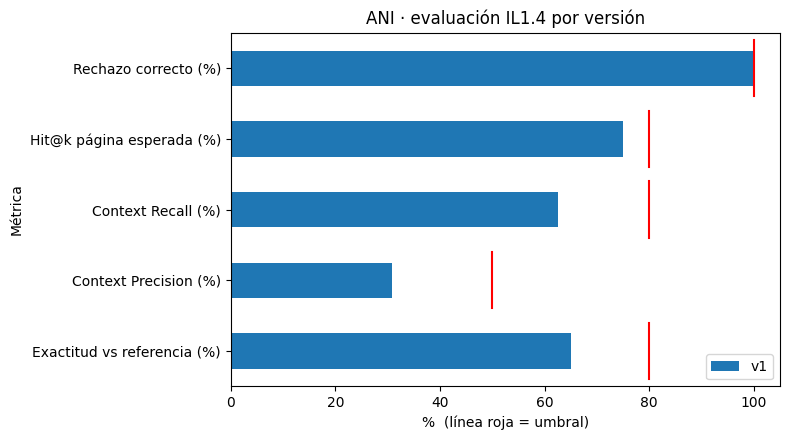


Guardado en Drive: ANI_evaluacion_IL14.xlsx y ANI_evaluacion_IL14.png


In [ ]:
# ============================================================
# PASO 13 · Evaluación con los criterios de RA1 · IL1.4
#   Recuperación: Context Precision, Context Recall, Hit@k (página esperada)
#   Generación:   Faithfulness (fidelidad), Answer Relevancy, Exactitud vs referencia
#   Juez: un LLM distinto al que responde (LLM-as-a-judge, temperatura 0)
# ============================================================
# Requisitos: haber corrido el Paso 12 (usa sus respuestas guardadas; NO vuelve a preguntarle a ANI).
# Gasta 1 consulta por pregunta (40 en total). Si se corta, vuelve a ejecutar: retoma donde quedó.

import os, re, json, time, glob
import pandas as pd
import matplotlib.pyplot as plt

VERSION = globals().get("VERSION", "v1")      # misma versión que el Paso 12
SUFIJO = "" if VERSION == "v1" else f"_{VERSION}"
JUECES = ["gemini-flash-latest", "gemini-3.5-flash", "gemini-3.1-flash-lite"]  # distinto al que responde, si hay cuota
PAUSA = 4
MAX_CHARS = 4000                              # por fragmento, para no reventar el contexto del juez

# Umbrales para decir "funciona" (definidos por el equipo; el curso no fija valores)
UMBRALES = {
    "Exactitud vs referencia (%)": 80,
    "Fidelidad promedio (/10)": 8,
    "Relevancia promedio (/10)": 8,
    "Context Precision (%)": 50,
    "Context Recall (%)": 80,
    "Hit@k página esperada (%)": 80,
    "Rechazo correcto (%)": 100,
}

# ---------- 1. Cargar preguntas y respuestas del Paso 12 ----------
candidatos = (glob.glob(os.path.join(CARPETA, "ANI_set_preguntas_prueba*.xlsx")) +
              glob.glob(os.path.join(os.path.dirname(CARPETA), "ANI_set_preguntas_prueba*.xlsx")))
df = pd.read_excel(sorted(candidatos)[-1], sheet_name="Preguntas")
df.columns = ["n", "pregunta", "dominio", "doc_esperado", "pagina", "rechazar",
              "mixta", "capacidad", "resp_esperada", "revision"][:len(df.columns)]
df["pagina"] = df["pagina"].fillna("").astype(str)
resp = json.load(open(os.path.join(CARPETA, f"ANI_resultados_evaluacion{SUFIJO}.json"), encoding="utf-8"))
print(f"{len(df)} preguntas · respuestas de ANI versión {VERSION}")

def paginas(texto):
    s = set()
    for a, b in re.findall(r"(\d+)(?:\.0)?\s*(?:[-–]\s*(\d+))?", str(texto)):
        a = int(a); b = int(b) if b else a
        s.update(range(a, b + 1))
    return s

def doc_clave(texto):
    return [c for c in ("Evaluaci", "Convivencia", "Decreto") if c in str(texto)]

SINONIMO = {"evaluación": "evaluacion", "convivencia": "convivencia"}

# ---------- 2. Reconstruir el contexto que recuperó el agente ----------
# Los embeddings son locales (e5-small): re-buscar no gasta cuota de Gemini.
def contexto(fila, r):
    frs = []
    consultas = r.get("consultas")
    if consultas:                                   # Paso 12 nuevo: consultas reales del agente
        for c in consultas:
            if c["herramienta"] == "buscar_norma_interna":
                frs += buscar(c["consulta"], "interna", k=4, dominio=c.get("dominio"))
            elif c["herramienta"] == "buscar_norma_externa":
                frs += buscar(c["consulta"], "externa", k=3)
    else:                                           # resultados antiguos: aproxima con la pregunta
        dom = SINONIMO.get(fila["dominio"])
        if "buscar_norma_interna" in r["herramientas"]:
            frs += buscar(fila["pregunta"], "interna", k=4, dominio=dom)
        if "buscar_norma_externa" in r["herramientas"]:
            frs += buscar(fila["pregunta"], "externa", k=3)
    vistos, unicos = set(), []
    for f in frs:
        clave = (f["documento"], f["ubicacion"], f["paginas"], f["texto"][:50])
        if clave not in vistos:
            vistos.add(clave); unicos.append(f)
    return unicos

def hit_pagina(frs, doc_esp, pag_esp):
    """¿Algún fragmento recuperado es del documento esperado y cubre la página (±1)?"""
    esperado = [c for c in doc_clave(doc_esp) if c != "Decreto"] or doc_clave(doc_esp)
    pe = paginas(pag_esp)
    for f in frs:
        if any(c in f["documento"] for c in esperado):
            if not pe or any(abs(p - q) <= 1 for p in paginas(f["paginas"]) for q in pe):
                return True
    return False

# ---------- 3. El juez ----------
PROMPT_JUEZ = """Eres un evaluador estricto de un sistema RAG que responde dudas de apoderados sobre reglamentos escolares.

PREGUNTA: {pregunta}

RESPUESTA DE REFERENCIA (correcta): {referencia}

FRAGMENTOS RECUPERADOS:
{fragmentos}

RESPUESTA DEL SISTEMA:
{respuesta}

Evalúa y responde SOLO con un JSON con estas claves:
- "fidelidad": entero 1-10. ¿Todo lo que afirma la respuesta está respaldado por los FRAGMENTOS? (1-3 inventa o contradice, 4-6 parcialmente, 7-10 totalmente). Si la respuesta solo dice que no está regulado, evalúa si eso es coherente con los fragmentos.
- "relevancia": entero 1-10. ¿Responde de forma directa y útil lo que preguntó el apoderado?
- "exactitud": "CORRECTO", "PARCIAL" o "INCORRECTO" comparando con la RESPUESTA DE REFERENCIA (no exijas coincidencia literal; un plazo, número o responsable distinto es INCORRECTO).
- "fragmentos_relevantes": lista con los números de los fragmentos útiles para responder (ej: [1, 3]); [] si ninguno.
- "contexto_suficiente": true si los fragmentos contienen la información de la referencia, false si no.
- "comentario": una frase con el problema principal, o "" si no hay."""

def juzgar(fila, r, frs):
    fragmentos = "\n\n".join(f"[F{i+1}] {f['documento']} | {f['ubicacion']} | pág. {f['paginas']}\n{f['texto'][:MAX_CHARS]}"
                             for i, f in enumerate(frs)) or "(ninguno: el agente no buscó)"
    prompt = PROMPT_JUEZ.format(pregunta=fila["pregunta"], referencia=fila["resp_esperada"],
                                fragmentos=fragmentos, respuesta=r["respuesta"])
    cfg = types.GenerateContentConfig(temperature=0, response_mime_type="application/json")
    for modelo in JUECES:
        for intento in range(3):
            try:
                out = client.models.generate_content(model=modelo, contents=prompt, config=cfg)
                datos = json.loads(re.sub(r"```json|```", "", out.text).strip())
                datos["juez"] = modelo
                return datos
            except Exception as e:
                error = str(e)
                if "PerDay" in error:
                    break
                if any(x in error for x in ("429", "503", "UNAVAILABLE")):
                    time.sleep(10 * (intento + 1)); continue
                if isinstance(e, json.JSONDecodeError):
                    continue
                raise
    return None

# ---------- 4. Correr el juez (con retoma) ----------
salida = os.path.join(CARPETA, f"ANI_juez_IL14{SUFIJO}.json")
juicios = json.load(open(salida, encoding="utf-8")) if os.path.exists(salida) else {}
fallos = 0
for _, fila in df.iterrows():
    k = str(int(fila["n"]))
    if k in juicios:
        continue
    if fallos >= 3:
        print("⛔ El juez se quedó sin cuota. Vuelve a ejecutar más tarde (retoma desde aquí)."); break
    r = resp[k]
    frs = contexto(fila, r)
    j = juzgar(fila, r, frs)
    if j is None:
        fallos += 1; continue
    fallos = 0
    j["n_fragmentos"] = len(frs)
    j["hit_pagina"] = hit_pagina(frs, fila["doc_esperado"], fila["pagina"])
    juicios[k] = j
    json.dump(juicios, open(salida, "w", encoding="utf-8"), ensure_ascii=False, indent=1)
    print(f"[{k:>2}/{len(df)}] {j['exactitud']:<10} fid {j['fidelidad']:>2} · rel {j['relevancia']:>2} · {j['juez']}")
    time.sleep(PAUSA)

faltan = [str(int(n)) for n in df["n"] if str(int(n)) not in juicios]
if faltan:
    raise RuntimeError(f"Faltan {len(faltan)} juicios ({', '.join(faltan)}). Vuelve a ejecutar cuando haya cuota.")

# ---------- 5. Métricas IL1.4 ----------
filas = []
for _, fila in df.iterrows():
    k = str(int(fila["n"])); j = juicios[k]; r = resp[k]
    rechazo = str(fila["rechazar"]).strip().lower() in ("sí", "si")
    nfr = j["n_fragmentos"]
    prec = (len(set(j["fragmentos_relevantes"]) & set(range(1, nfr + 1))) / nfr) if (nfr and not rechazo) else None
    exact = {"CORRECTO": 1, "PARCIAL": 0.5, "INCORRECTO": 0}.get(str(j["exactitud"]).upper(), 0)
    # Diagnóstico IL1.4: ¿falla el recuperador o el generador?
    if exact == 1 and j["fidelidad"] >= 7:
        diag = "OK"
    elif rechazo:
        diag = "rechazo mal resuelto"
    elif not j["contexto_suficiente"]:
        diag = "falla de RECUPERACIÓN (el dato no llegó)"
    elif j["fidelidad"] < 7:
        diag = "falla de GENERACIÓN (alucina)"
    else:
        diag = "falla de GENERACIÓN (tenía el dato y no lo usó)"
    filas.append({"n": int(fila["n"]), "pregunta": fila["pregunta"], "capacidad": fila["capacidad"],
                  "respuesta_esperada": fila["resp_esperada"], "respuesta_ANI": r["respuesta"],
                  "exactitud": j["exactitud"], "exactitud_num": exact, "fidelidad": j["fidelidad"],
                  "relevancia": j["relevancia"], "context_precision": prec,
                  "context_recall": None if rechazo else bool(j["contexto_suficiente"]),
                  "hit_pagina": None if rechazo else bool(j["hit_pagina"]),
                  "rechazo_ok": ("no está regulado" in r["respuesta"].lower()) if rechazo else None,
                  "segundos": r["segundos"], "diagnostico": diag, "comentario_juez": j.get("comentario", ""),
                  "juez": j["juez"]})
res = pd.DataFrame(filas)
nr = res[res["context_recall"].notna()]

valores = {
    "Exactitud vs referencia (%)": res["exactitud_num"].mean() * 100,
    "Fidelidad promedio (/10)": res["fidelidad"].mean(),
    "Relevancia promedio (/10)": res["relevancia"].mean(),
    "Context Precision (%)": nr["context_precision"].astype(float).mean() * 100,
    "Context Recall (%)": nr["context_recall"].astype(bool).mean() * 100,
    "Hit@k página esperada (%)": nr["hit_pagina"].astype(bool).mean() * 100,
    "Rechazo correcto (%)": res["rechazo_ok"].dropna().astype(bool).mean() * 100,
}
metricas = pd.DataFrame([{"Métrica": m, "Valor": round(v, 1), "Umbral": UMBRALES[m],
                          "¿Cumple?": "✅" if v >= UMBRALES[m] else "❌"} for m, v in valores.items()])
metricas.loc[len(metricas)] = ["Latencia mediana (s)", round(res["segundos"].median(), 1), "—", "—"]
print(f"\n=== Evaluación IL1.4 · versión {VERSION} ===")
print(metricas.to_string(index=False))

cumple = (metricas["¿Cumple?"] == "✅").sum(); total = len(UMBRALES)
print(f"\nVeredicto: {cumple}/{total} criterios cumplidos →",
      "FUNCIONA" if cumple == total else "FUNCIONA PARCIALMENTE" if cumple >= total / 2 else "NO FUNCIONA AÚN")

print("\nDiagnóstico por componente (qué falla):")
print(res["diagnostico"].value_counts().to_string())
print("\nPreguntas con problemas:")
for _, f in res[res["diagnostico"] != "OK"].iterrows():
    print(f"  #{f['n']:>2} [{f['diagnostico']}] {f['pregunta']}\n       → {f['comentario_juez']}")

# ---------- 6. Guardar + comparar versiones ----------
xlsx = os.path.join(CARPETA, f"ANI_evaluacion_IL14{SUFIJO}.xlsx")
with pd.ExcelWriter(xlsx) as w:
    metricas.to_excel(w, sheet_name="Métricas", index=False)
    res.to_excel(w, sheet_name="Detalle", index=False)

comparacion = {}
for archivo in sorted(glob.glob(os.path.join(CARPETA, "ANI_evaluacion_IL14*.xlsx"))):
    m = re.search(r"IL14_?(v\d+)?\.xlsx$", archivo)
    ver = (m.group(1) if m and m.group(1) else "v1")
    tabla = pd.read_excel(archivo, sheet_name="Métricas").set_index("Métrica")["Valor"]
    comparacion[ver] = tabla
comp = pd.DataFrame(comparacion).loc[list(UMBRALES)]
if comp.shape[1] > 1:
    print("\nComparación entre versiones:")
    print(comp.to_string())

pct = [m for m in UMBRALES if "%" in m]
ax = comp.loc[pct].plot(kind="barh", figsize=(8, 4.5))
for i, m in enumerate(pct):
    ax.plot([UMBRALES[m]] * 2, [i - 0.4, i + 0.4], color="red", lw=1.5)
ax.set_xlim(0, 105); ax.set_xlabel("%  (línea roja = umbral)")
ax.set_title("ANI · evaluación IL1.4 por versión"); plt.tight_layout()
plt.savefig(os.path.join(CARPETA, "ANI_evaluacion_IL14.png"), dpi=200); plt.show()
print(f"\nGuardado en Drive: {os.path.basename(xlsx)} y ANI_evaluacion_IL14.png")